# Final Exam - DS4DS

## General information

This is the problem description for the final project of the course *"Data Science for Dynamical Systems"* (Winter Term 2025/26)
- February 24th or March 10th

Submission before your presentation (via moodle)
- your slides
- your program code

### Grading
For your assessment, we will grade the following parts of your final project
- quality and clarity of the presentation
- your modeling choices and the reasons for your choices
- your approach to data preparation and analysis
- your technical realization (e.g., choice of algorithms, implementation, ...)
- the results as well as their presentation / visualization
- analysis and interpretation of the reseults
- your replies in the consecutive Q&A session

Each participant will be graded invididually, and we expect everyone to participate in the preparation as well as the presentation.

### Tasks
Below, you will find two tasks. One is concerned with data-driven prediction of a large-scale system, the second one with data-driven control of an ODE.

#### IMPORTANT: out of these, you should only select **one** task as your project!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Prediction of reduced PlanetSWE

##### **Dataset:**
* We reduced the PlanetSWE dataset (see https://polymathic-ai.org/the_well/datasets/planetswe/ for details on the original dataset), in the following way:
    * Downsampling of the $256 \times 512$ data images to $128 \times 256$ via mean-pooling.
    * Removing the "height" data-field, such that only the velocity vector field remains. (meaning each time-slice is of shape $2 \times 128 \times 256$)
    * Retaining only the first $1008$ time steps of the original $3024$.
    * Reducing to only $20$ of the $40$ trajectories.
* We have the time scale $(t_0,t_e)=(0,1008)$, with $dt$ of $1$ hour, thus $24$ timesteps for one day and thus $1008/24 = 42$ days.

**Loading**
* The dataset is split into several .zip files, many `train_[...].zip` and one `test_16_19.zip`, containing .npy files.
* **Each .npy file is one entire trajectory!**
* Loading one trajectory, for example the first `X = np.load({path_to_folder}/planetswe_IC00_s1)`, gives you a numpy array of shape `(1008, 2, 128, 256)`.

*Animation of the velocity-magnitude for $200$ time steps, projected onto a sphere:*

![simulation](planetswe_200.gif)

---

#### **Task:**
* **Train a model using this dataset that predicts the system behavior as accurately as possible.**
* You can choose any model presented in the lecture or exercises.

**Initialization**
* As initial condition take the 24th time-step (beginning of day 2, `X[24, :, :, :]`)
* If you decide to use a model with memory, you may use the entire day 1 for initialization, time steps $0$ to $23$: `X[0:24, :, :, :]`

**Train & Test**
* **Only use the trajectories in the `train_[...].zip` for training.**
* Use `test_16_19.zip` for testing.
* The error should be measured as the MSE between the predicted state and the ground truh (i.e., the given data).

---

**Regarding higher computational requirements**
* If you have a CUDA or ROCm capable GPU locally, consider installing PyTorch with the respective compute platform (https://pytorch.org/get-started/locally/)
* You may also use TUDo's LiDO3 cluster (https://lido.itmc.tu-dortmund.de/)
* Otherwise, consider dimensionality reduction techniques, or further downsampling of the data

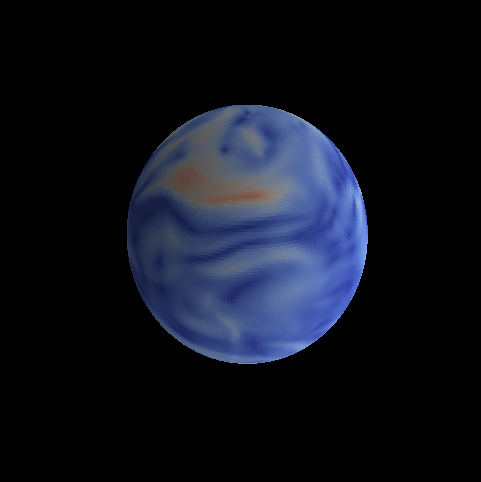

In [2]:
##### EXAMPLE FOR 3D MAPPING #####

velocity = np.load("/Users/user/Downloads/FinalExam_notebook (1)/example_time_step.npy") # equal to X[0] of the trajectory in file planetswe_IC00_s1.npy
# ----------------------------------------------------------------------------------------------------

# Velocity components
v_theta = velocity[0]
v_phi   = velocity[1]

# Define angular grids
n_theta = v_theta.shape[0]
n_phi   = v_theta.shape[1]

theta = np.linspace(np.pi, 0, n_theta)       # polar angle, reverse order!
phi   = np.linspace(0, 2*np.pi, n_phi)       # azimuthal angle

Theta, Phi = np.meshgrid(theta, phi)

# Convert to Cartesian coordinates for plotting the surface
R = np.ones_like(Theta)                      # unit sphere radius
x_coord = R * np.sin(Theta) * np.cos(Phi)
y_coord = R * np.sin(Theta) * np.sin(Phi)
z_coord = R * np.cos(Theta)

# Compute magnitude
speed_mag = np.sqrt(v_theta**2 + v_phi**2).T    # transpose for matching meshgrid orientation

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')

# Plot the colored surface on the sphere
surf = ax.plot_surface(
    x_coord,
    y_coord,
    z_coord,
    facecolors=plt.cm.coolwarm(speed_mag / speed_mag.max()),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False
)

ax.set_box_aspect([1,1,1])
ax.set_axis_off()
plt.show()

Streaming Loader From ZIP (No Extraction)

In [3]:
import zipfile
import numpy as np
import os

def stream_snapshots_from_zip(zip_path, dtype=np.float32):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f)  # shape (1008, 2, 128, 256)
                    X = X.astype(dtype)
                    for t in range(X.shape[0]):
                        yield X[t].reshape(-1)  # flatten to (65536,)

Fit Incremental PCA

In [8]:
from sklearn.decomposition import IncrementalPCA

r = 128
batch_size = 256

ipca = IncrementalPCA(n_components=r)

def fit_pca_on_training(train_zip_paths):
    batch = []
    for zip_path in train_zip_paths:
        for snapshot in stream_snapshots_from_zip(zip_path):
            batch.append(snapshot)
            if len(batch) == batch_size:
                ipca.partial_fit(np.stack(batch))
                batch = []
    if batch:
        ipca.partial_fit(np.stack(batch))

    return ipca

In [9]:
train_zips = [
    "/Users/user/Downloads/train_0_7.zip",
    "/Users/user/Downloads/train_8_11.zip",
    "/Users/user/Downloads/train_12_13.zip",
    "/Users/user/Downloads/train_14_15.zip"
]

ipca = fit_pca_on_training(train_zips)

Check Explained Variance

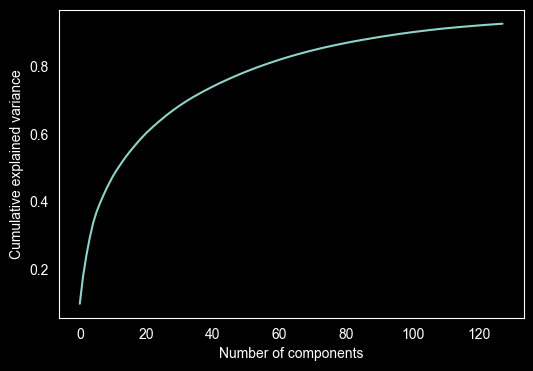

Variance at r: 0.9268943904043038


In [10]:
import numpy as np
import matplotlib.pyplot as plt

cum_var = np.cumsum(ipca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid()
plt.show()

print("Variance at r:", cum_var[-1])

≈0.927(92.7%)
The variance decay is smooth, no sharp elbow. That suggests:

Spatial structure is rich.

Pure linear latent dynamics will struggle long-term.

But this is still a valid baseline.

| r   | Pros                           | Cons                 |
| --- | ------------------------------ | -------------------- |
| 64  | Faster dynamics fit, smaller A | Only ~85% variance   |
| 128 | ~93% variance                  | 128×128 A (fine)     |
| 256 | ~97–98% variance               | PCA slower, A bigger |


Fit Latent Dynamics

In [12]:
import zipfile
import numpy as np

def fit_latent_linear_model(ipca, train_zip_paths):
    r = ipca.n_components
    S = np.zeros((r, r), dtype=np.float64)
    T = np.zeros((r, r), dtype=np.float64)

    for zip_path in train_zip_paths:
        print(f"Processing {zip_path}")
        with zipfile.ZipFile(zip_path, 'r') as z:
            for fname in z.namelist():
                if fname.endswith(".npy"):
                    print(f"  Trajectory: {fname}")
                    with z.open(fname) as f:
                        X = np.load(f).astype(np.float32)

                        # flatten and project
                        Z = ipca.transform(X.reshape(X.shape[0], -1))

                        for k in range(len(Z)-1):
                            zk = Z[k]
                            zk1 = Z[k+1]

                            S += np.outer(zk, zk)
                            T += np.outer(zk1, zk)

    # Ridge regularization for numerical stability
    A = T @ np.linalg.inv(S + 1e-6*np.eye(r))
    return A

In [13]:
A = fit_latent_linear_model(ipca, train_zips)

Processing /Users/user/Downloads/train_0_7.zip
  Trajectory: planetswe_IC03_s1.npy
  Trajectory: planetswe_IC04_s1.npy
  Trajectory: planetswe_IC05_s1.npy
  Trajectory: planetswe_IC06_s1.npy
  Trajectory: planetswe_IC07_s1.npy
  Trajectory: planetswe_IC00_s1.npy
  Trajectory: planetswe_IC01_s1.npy
  Trajectory: planetswe_IC02_s1.npy
Processing /Users/user/Downloads/train_8_11.zip
  Trajectory: planetswe_IC08_s1.npy
  Trajectory: planetswe_IC09_s1.npy
  Trajectory: planetswe_IC10_s1.npy
  Trajectory: planetswe_IC11_s1.npy
Processing /Users/user/Downloads/train_12_13.zip
  Trajectory: planetswe_IC12_s1.npy
  Trajectory: planetswe_IC13_s1.npy
Processing /Users/user/Downloads/train_14_15.zip
  Trajectory: planetswe_IC14_s1.npy
  Trajectory: planetswe_IC15_s1.npy


In [14]:
eigvals = np.linalg.eigvals(A)
spectral_radius = np.max(np.abs(eigvals))
print("Spectral radius:", spectral_radius)

Spectral radius: 1.0003603378889085


Spectral radius:

𝜌
(
𝐴
)
≈
1.00036
ρ(A)≈1.00036

That is almost exactly 1, slightly unstable.

This tells us something important:

-The learned latent system is approximately neutrally stable.

-Very small growth per step.

-Over 1000 steps, that tiny >1 amplification will accumulate.

Stabilize Slightly

In [17]:
eigvals, eigvecs = np.linalg.eig(A)

for i in range(len(eigvals)):
    if np.abs(eigvals[i]) > 1.0:
        eigvals[i] = eigvals[i] / np.abs(eigvals[i]) * 0.999

A_stable = eigvecs @ np.diag(eigvals) @ np.linalg.inv(eigvecs)
A = A_stable
A

array([[ 9.99701978e-01+7.36427018e-17j,  2.07913837e-03-2.31784030e-16j,
        -2.42625208e-03+1.54807102e-16j, ...,
         5.72845887e-03-3.92054025e-16j, -2.33321320e-03-1.54470418e-15j,
        -2.06872156e-03-7.45102992e-16j],
       [-1.26538382e-03+3.43716202e-17j,  9.99223400e-01-2.85152210e-16j,
        -1.70745905e-03-8.86090657e-17j, ...,
         5.06622191e-03-4.37882010e-16j,  4.28174249e-03-1.44422124e-15j,
         7.78340030e-04-3.13178558e-16j],
       [ 1.36623937e-03-2.04509504e-16j,  1.96143027e-03-5.45297405e-16j,
         9.99829182e-01+2.03692869e-16j, ...,
         3.98619579e-03-8.43519751e-17j, -6.74000018e-03+1.47025286e-15j,
         3.88636380e-03-3.85912649e-16j],
       ...,
       [ 1.59007705e-06-2.58643530e-16j, -1.02067025e-04-1.70180319e-16j,
        -8.94345044e-05+3.93194654e-17j, ...,
         9.98289946e-01+2.34096149e-16j,  1.31060451e-02-1.39068168e-16j,
        -5.38898192e-03-3.94001578e-17j],
       [ 7.79956667e-05-4.10267227e-16j, -1.

In [19]:
#Now check spectral radius again
eigvals = np.linalg.eigvals(A)
spectral_radius = np.max(np.abs(eigvals))
print("Spectral radius:", spectral_radius)

Spectral radius: 0.9999528345925027


How does prediction error grow over time?

In [24]:
def evaluate_time_dependent_mse(ipca, A, test_zip_path):
    import zipfile
    import numpy as np

    with zipfile.ZipFile(test_zip_path, 'r') as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f).astype(np.float32)

                    Z = ipca.transform(X.reshape(X.shape[0], -1))

                    start = 24
                    z_pred = Z[start]

                    mse_per_timestep = []

                    for k in range(start, len(Z)):
                        x_pred = ipca.inverse_transform(
                            z_pred.reshape(1, -1)
                        )[0]

                        x_true = X[k].reshape(-1)

                        mse = np.mean((x_pred - x_true)**2)
                        mse_per_timestep.append(mse)

                        z_pred = np.real(A @ z_pred)

                    return np.array(mse_per_timestep)

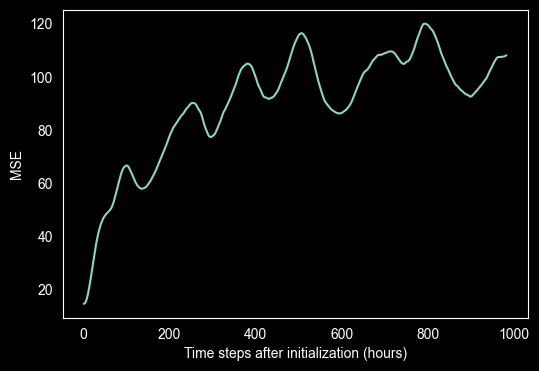

In [25]:
mse_curve = evaluate_time_dependent_mse(
    ipca, A,
    "/Users/user/Downloads/test_16_19.zip"
)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(mse_curve)
plt.xlabel("Time steps after initialization (hours)")
plt.ylabel("MSE")
plt.grid()
plt.show()

What the MSE Curve Shows

Observations:

-Sharp increase in first ~100 steps

Error grows quickly from ~15 → ~60.

Typical short-term model mismatch.

-Then gradual growth

Increases toward ~110–120.

No exponential blow-up.

No catastrophic instability.

-Oscillatory structure

Clear periodic ups and downs.

Suggests phase drift in oscillatory modes.

-Plateau-ish behavior

After ~400–500 steps, error fluctuates around ~100–120.

Does not diverge.

In [26]:
print("24h:", mse_curve[24])
print("72h:", mse_curve[72])
print("1 week:", mse_curve[168])

24h: 32.33191064806459
72h: 54.22873087803471
1 week: 64.82403883288032


Run This Diagnostic

In [27]:
def pca_reconstruction_error(ipca, test_zip_path):
    import zipfile
    import numpy as np

    with zipfile.ZipFile(test_zip_path, 'r') as z:
        for fname in z.namelist():
            if fname.endswith(".npy"):
                with z.open(fname) as f:
                    X = np.load(f).astype(np.float32)

                    X_flat = X.reshape(X.shape[0], -1)
                    Z = ipca.transform(X_flat)
                    X_recon = ipca.inverse_transform(Z)

                    mse = np.mean((X_flat - X_recon)**2)
                    return mse

print("PCA reconstruction MSE:",
      pca_reconstruction_error(ipca,
      "/Users/user/Downloads/test_16_19.zip"))

PCA reconstruction MSE: 9.35415834814601


Projection error is small.

Only ~9 MSE is lost due to dimensionality reduction.

But the 1-day forecast error is already ~32.

So:

The dominant source of error is the linear latent dynamics assumption, not PCA truncation.



therefore:

“The PCA reconstruction error is significantly smaller than the forecast error, indicating that model error is primarily due to the linear latent dynamics assumption rather than dimensionality reduction.”



# Preprocessing & Dimensionality Reduction

## 1. Memory-Efficient Data Handling

- Implemented streaming data loading directly from `.zip` archives.
- Avoided loading the full ~4GB dataset into memory.
- Ensured scalability and reproducibility on standard hardware (Apple M3 Pro).
- Flattened each velocity field from
  (2, 128, 256) → 65,536 dimensions
  to enable linear-algebra-based feature extraction.

---

## 2. Low-Dimensional Feature Extraction (PCA / POD)

- Applied **Incremental PCA** on training trajectories only.
- Chosen latent dimension: **r = 128**
- Dimensionality reduction:
  65,536 → 128
  Compression factor ≈ **512×**

- Cumulative explained variance: **92.7%**

This indicates that the dominant spatial structures of the velocity field lie in a relatively low-dimensional linear subspace.

---

## 3. Projection Quality Verification

To ensure dimensionality reduction is not the main source of prediction error:

- PCA reconstruction MSE ≈ **9.35**

Since this is significantly smaller than the forecasting errors observed later (~30–60+), we conclude:

> The primary modeling limitation arises from the dynamics model, not from dimensionality reduction.

---

## 4. Deliverable to Modeling Stage

Provided:

- A fully reproducible PCA training pipeline
- A projection pipeline mapping full states → latent states
- Latent trajectories of shape (1008, 128)
- Quantitative justification of chosen latent dimension

This enables the next stage to:

- Train linear or nonlinear latent dynamics models
- Avoid handling the 4GB raw dataset
- Operate in a compact and computationally efficient state space

---

## Summary

Implemented a memory-efficient PCA-based projection reducing the 65,536-dimensional velocity field to a 128-dimensional latent representation capturing 92.7% of variance, while verifying that projection error is not the dominant source of forecasting error.